# NAMpy core workflow

This notebook teaches NAMpy's common modeling language once. Statistical
GAMs and neural additive models use different fitting algorithms, but
they share an estimator interface and an additive explanation contract.
Later notebooks can therefore focus on model-specific theory rather than
repeating `fit`, prediction, reconstruction, sklearn, and persistence.

**Execution modes.** The checked-in notebook uses `FAST_MODE=True`.
Change it to `False` for larger samples and longer neural training.


## 1. Additive models as structured predictors

An additive model represents a linear predictor as

$$
\eta_i = \beta_0 + \sum_{j=1}^p f_j(x_{ij})
+ \sum_{(j,k)\in\mathcal I} f_{jk}(x_{ij},x_{ik}) + o_i.
$$

The main-effect functions $f_j$ describe one feature at a time;
interaction functions $f_{jk}$ describe departures from those main
effects. The offset $o_i$ is known in advance and has coefficient one.
Identifiability constraints center or otherwise anchor the functions so
that the intercept and terms have stable meanings.

A link function connects the additive predictor to the conditional mean,
$g(\mu_i)=\eta_i$. Gaussian identity-link regression has $\mu_i=\eta_i$.
Binary logistic regression has $\mu_i=\operatorname{logit}^{-1}(\eta_i)$.
Additivity is therefore a statement about the **link scale**, not usually
about the response scale.

Ordinary regression models one location or mean. Distributional
regression assigns a separate additive predictor to each distribution
parameter, for example $\mu(x)$ and $\sigma(z)$ in a normal
location-scale model.


## 2. Synthetic datasets used throughout


In [1]:
from pathlib import Path
import tempfile
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore", category=FutureWarning)
plt.style.use("seaborn-v0_8-whitegrid")
COLORS = ["#2563EB", "#F97316", "#10B981", "#8B5CF6", "#EF4444"]

FAST_MODE = True
N_SAMPLES = 160 if FAST_MODE else 5000
MAX_EPOCHS = 2 if FAST_MODE else 150
MAX_STEPS = 2 if FAST_MODE else -1
RANDOM_STATE = 7
CHECKPOINT_ROOT = Path(tempfile.mkdtemp(prefix="nampy-notebook-"))

NEURAL_FIT_KWARGS = {
    "max_epochs": MAX_EPOCHS,
    "max_steps": MAX_STEPS,
    "batch_size": 64 if FAST_MODE else 256,
    "random_state": RANDOM_STATE,
    "checkpoint_path": CHECKPOINT_ROOT,
    "logger": False,
    "enable_progress_bar": False,
    "enable_model_summary": False,
    "num_sanity_val_steps": 0,
}

rng = np.random.default_rng(RANDOM_STATE)

n = N_SAMPLES
x1 = rng.uniform(-1.0, 1.0, n)
x2 = rng.normal(size=n)
group = pd.Categorical(rng.choice(["a", "b", "c"], size=n))

X = pd.DataFrame({"x1": x1, "x2": x2, "group": group})
main_signal = np.sin(np.pi * x1) + 0.35 * x2**2 + 0.30 * (group == "b")
y_reg = main_signal + rng.normal(0.0, 0.18, n)

logit = -0.3 + 1.8 * np.sin(np.pi * x1) - 0.7 * x2 + 0.5 * (group == "c")
p_binary = 1.0 / (1.0 + np.exp(-logit))
y_binary = rng.binomial(1, p_binary)

sigma = np.exp(-1.1 + 0.55 * (x2 - x2.mean()))
y_hetero = np.sin(np.pi * x1) + sigma * rng.normal(size=n)

X_sparse = pd.DataFrame({f"x{j}": rng.normal(size=n) for j in range(1, 7)})
y_sparse = (
    np.sin(X_sparse["x1"])
    + 0.8 * X_sparse["x2"] * X_sparse["x3"]
    + rng.normal(0.0, 0.2, n)
)

datasets = {
    "nonlinear regression": (X, y_reg),
    "binary classification": (X, y_binary),
    "heteroscedastic regression": (X[["x1", "x2"]], y_hetero),
    "sparse interaction problem": (X_sparse, y_sparse),
}
pd.DataFrame(
    {"dataset": name, "rows": len(features), "features": features.shape[1]}
    for name, (features, target) in datasets.items()
)


,dataset,rows,features
0,nonlinear regression,160,3
1,binary classification,160,3
2,heteroscedastic regression,160,2
3,sparse interaction problem,160,6


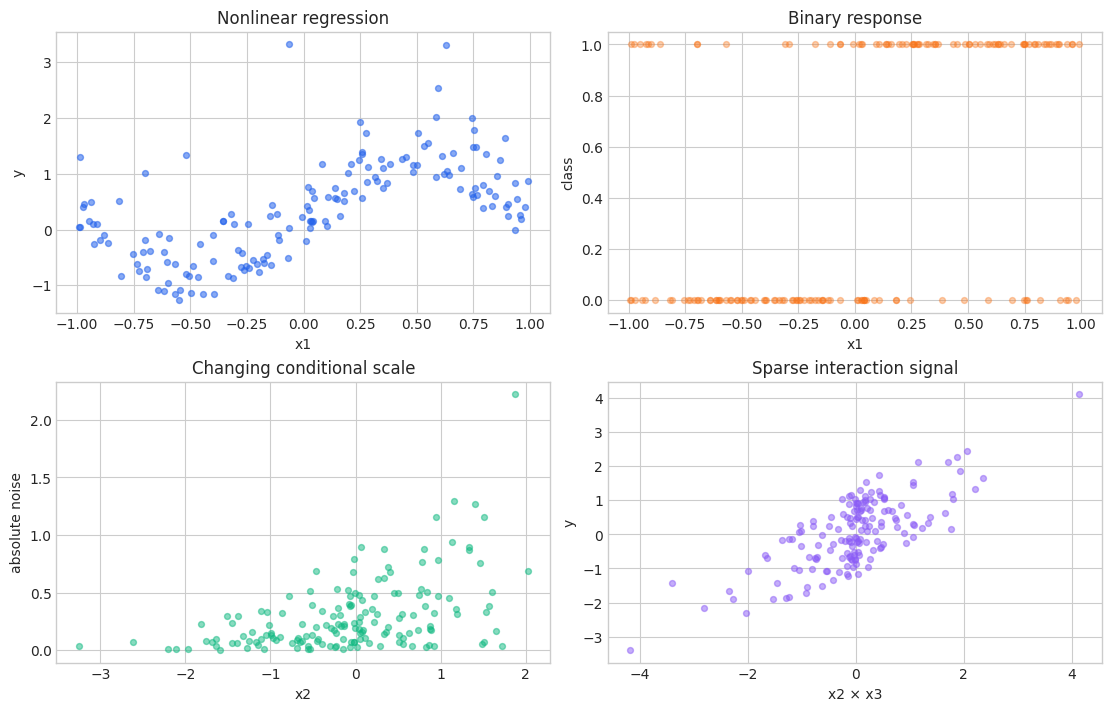

In [2]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7), constrained_layout=True)
axes[0, 0].scatter(X["x1"], y_reg, s=18, alpha=0.55, color=COLORS[0])
axes[0, 0].set(title="Nonlinear regression", xlabel="x1", ylabel="y")
axes[0, 1].scatter(X["x1"], y_binary, s=18, alpha=0.35, color=COLORS[1])
axes[0, 1].set(title="Binary response", xlabel="x1", ylabel="class")
axes[1, 0].scatter(X["x2"], np.abs(y_hetero - np.sin(np.pi * x1)), s=18, alpha=0.5, color=COLORS[2])
axes[1, 0].set(title="Changing conditional scale", xlabel="x2", ylabel="absolute noise")
axes[1, 1].scatter(X_sparse["x2"] * X_sparse["x3"], y_sparse, s=18, alpha=0.5, color=COLORS[3])
axes[1, 1].set(title="Sparse interaction signal", xlabel="x2 × x3", ylabel="y")
plt.show()
plt.close(fig)


## 3. First statistical and neural additive models

A GAM expands each smooth in a basis and controls roughness through a
quadratic penalty. A NAM replaces each univariate smooth with a small
neural network. Both return term-wise contributions, but their inductive
biases differ: spline penalties favor smooth low-curvature functions;
neural networks use architecture, optimization, dropout, and weight
regularization.


In [3]:
from sklearn.model_selection import train_test_split
from nampy.models import GAMRegressor, NAMRegressor

train_index, test_index = train_test_split(
    np.arange(n), test_size=0.25, random_state=RANDOM_STATE
)
X_train, X_test = X.iloc[train_index], X.iloc[test_index]
y_train, y_test = y_reg[train_index], y_reg[test_index]

gam_train = X_train.assign(y=y_train)
gam = GAMRegressor(
    formula="y ~ s(x1, bs='cr', k=9) + s(x2, bs='cr', k=9) + group",
    smoothing_method="reml",
).fit(gam_train)

nam = NAMRegressor(
    layer_sizes=[24, 12],
    dropout=0.0,
    numerical_preprocessing="minmax",
    categorical_preprocessing="one-hot",
)
nam.fit(X_train, y_train, **NEURAL_FIT_KWARGS)

comparison = pd.DataFrame(
    {
        "model": ["GAMRegressor", "NAMRegressor"],
        "test R2": [gam.score(X_test, y_test), nam.score(X_test, y_test)],
        "prediction shape": [gam.predict(X_test).shape, nam.predict(X_test).shape],
    }
)
comparison


/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


GPU available: False, used: False


TPU available: False, using: 0 TPU cores


/home/ad32/.local/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
/home/ad32/.local/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


/home/ad32/.local/lib/python3.10/site-packages/lightning/pytorch/core/module.py:522: You called `self.log('train_loss', ..., logger=True)` but have no logger configured. You can enable one by doing `Trainer(logger=ALogger(...))`
/home/ad32/.local/lib/python3.10/site-packages/lightning/pytorch/core/module.py:522: You called `self.log('val_loss', ..., logger=True)` but have no logger configured. You can enable one by doing `Trainer(logger=ALogger(...))`


`Trainer.fit` stopped: `max_steps=2` reached.


,model,test R2,prediction shape
0,GAMRegressor,0.966000,"(40,)"
1,NAMRegressor,-0.420434,"(40,)"


## 4. The shared estimator interface

NAMpy estimators follow sklearn conventions: constructor arguments are
hyperparameters, `fit` learns trailing-underscore attributes, `predict`
returns task-appropriate outputs, and `score` follows sklearn's
higher-is-better convention. `get_params` and `set_params` make cloning,
pipelines, and searches possible. DataFrame column names become the
fitted feature schema. Prediction validates both names and order.

Sample weights change the empirical objective. They are distinct from an
offset, which changes the linear predictor with a fixed coefficient.


In [4]:
interface_report = pd.DataFrame(
    {
        "operation": ["fit", "predict", "score", "get_params", "set_params"],
        "GAM": [hasattr(gam, name) for name in ["fit", "predict", "score", "get_params", "set_params"]],
        "NAM": [hasattr(nam, name) for name in ["fit", "predict", "score", "get_params", "set_params"]],
    }
)

clone_candidate = NAMRegressor(layer_sizes=[8]).set_params(dropout=0.05)
display(interface_report)
display({
    "feature names": nam.feature_names_in_.tolist(),
    "dropout after set_params": clone_candidate.get_params(deep=False)["dropout"],
})

sample_weight = np.where(X_train["x1"].to_numpy() > 0, 2.0, 1.0)
weighted_gam = GAMRegressor(k=8, basis="cr").fit(
    X_train[["x1", "x2"]], y_train, sample_weight=sample_weight
)


,operation,GAM,NAM
0,fit,True,True
1,predict,True,True
2,score,True,True
3,get_params,True,True
4,set_params,True,True


{'feature names': ['x1', 'x2', 'group'], 'dropout after set_params': 0.05}

## 5. The shared interpretation contract

`predict_components` returns an `AdditivePrediction` with `intercept`,
optional `offset`, named `terms`, reconstructed `link`, and final
`response`. `explain_terms` bins those contributions for plotting.
`term_importance` reports mean absolute link-scale contribution;
`interaction_importance` filters interaction terms.

Importance measures magnitude, not causality. Correlated predictors can
redistribute signal, and centering changes the intercept/term allocation
without changing predictions.


In [5]:
component_rows = []
def reconstruct_components(components):
    link = np.asarray(components.link)
    def aligned(value):
        array = np.asarray(value, dtype=float)
        if link.ndim == 1 and array.shape == (link.shape[0], 1):
            return array[:, 0]
        if link.ndim == 2 and array.shape == (link.shape[0],):
            return array[:, None]
        return array
    reconstruction = aligned(components.intercept)
    for contribution in components.terms.values():
        reconstruction = reconstruction + aligned(contribution)
    if components.offset is not None:
        reconstruction = reconstruction + aligned(components.offset)
    return reconstruction

for fitted_model in (gam, nam):
    components = fitted_model.predict_components(X_test)
    components.validate_additive_reconstruction(rtol=1e-5, atol=1e-6)
    reconstruction = reconstruct_components(components)
    component_rows.append({
        "model": type(fitted_model).__name__,
        "terms": len(components.terms),
        "max reconstruction error": float(np.max(np.abs(reconstruction - components.link))),
        "backend": components.backend,
    })

display(pd.DataFrame(component_rows))
display(gam.term_importance(X_test))
display(nam.explain_terms(X_test, max_bins=16, center=True).head(10))
display(nam.interaction_importance(X_test, center=True))


,model,terms,max reconstruction error,backend
0,GAMRegressor,3,2.220446e-16,gam
1,NAMRegressor,3,4.596950e-08,neural


,term,term_type,output,importance
0,"s(x1, bs='cr', k=9)",main,0,0.583998
1,"s(x2, bs='cr', k=9)",main,0,0.296041
2,group[b],main,0,0.081367


,term,term_type,output,value,contribution,count,importance
0,x1,main,0,-0.984,0.014675,3,0.011422
1,x1,main,0,-0.952,0.014395,2,0.011422
2,x1,main,0,-0.8635,0.013722,3,0.011422
3,x1,main,0,-0.7275,0.012360,2,0.011422
4,x1,main,0,-0.6,0.010522,3,0.011422
5,x1,main,0,-0.5095,0.008461,2,0.011422
6,x1,main,0,-0.4015,0.006419,3,0.011422
7,x1,main,0,-0.235,0.004959,2,0.011422
8,x1,main,0,-0.0215,0.004236,2,0.011422
9,x1,main,0,0.1515,0.001027,3,0.011422


,term,term_type,output,importance


## 6. Link scale and response scale

With an identity link, a one-unit term contribution is a one-unit change
in the conditional mean. With a nonlinear inverse link, contributions
add before transformation. For a logistic model,

$$p_i=\frac{1}{1+\exp(-\eta_i)},\qquad
\eta_i=\beta_0+\sum_j f_j(x_{ij}).$$

Applying the logistic function to each term separately and adding the
results is mathematically wrong. The response-scale effect of a term
depends on the row's other terms through the current value of $\eta$.


In [6]:
from nampy.models import GAMClassifier

binary_train = X.iloc[train_index].assign(y=y_binary[train_index])
classifier = GAMClassifier(
    formula="y ~ s(x1, bs='cr', k=8) + s(x2, bs='cr', k=8) + group"
).fit(binary_train, binary_train["y"])

gaussian_components = gam.predict_components(X_test)
logistic_components = classifier.predict_components(X_test)
gaussian_components.validate_additive_reconstruction()
logistic_components.validate_additive_reconstruction()

display(pd.DataFrame({
    "scale": ["Gaussian link", "Gaussian response", "logistic link", "class-1 probability"],
    "first prediction": [
        gaussian_components.link[0], gaussian_components.response[0],
        logistic_components.link[0], logistic_components.response[0],
    ],
}))


,scale,first prediction
0,Gaussian link,0.724327
1,Gaussian response,0.724327
2,logistic link,0.292609
3,class-1 probability,0.572635


## 7. Scikit-learn integration

Because preprocessing is already part of neural estimators, they can be
placed directly in a pipeline. GAM array adapters also compose with
external transformers. Cross-validation estimates generalization;
`GridSearchCV` clones the estimator for every candidate, so all modeling
choices must be constructor parameters. Custom scorers should respect the
task's response scale.


In [7]:
from sklearn.base import clone
from sklearn.model_selection import GridSearchCV, KFold, cross_val_score
from sklearn.pipeline import Pipeline

numeric_X = X[["x1", "x2"]]
pipeline = Pipeline([
    ("model", GAMRegressor(optimize_smoothing=False, smoothing_method="fixed", smoothing_params=[0.7, 0.7])),
])
cv = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(pipeline, numeric_X, y_reg, cv=cv, scoring="r2")

search = GridSearchCV(
    pipeline,
    {"model__k": [6, 9]},
    cv=cv,
    scoring="neg_mean_squared_error",
).fit(numeric_X, y_reg)

display({
    "mean CV R2": float(cv_scores.mean()),
    "best parameters": search.best_params_,
    "clone class": type(clone(nam)).__name__,
})


{'mean CV R2': 0.7857520100317851,
 'best parameters': {'model__k': 9},
 'clone class': 'NAMRegressor'}

## 8. Persistence and reproducibility

`save_model` stores the fitted estimator, preprocessing state, schema,
and model parameters. Load with the same estimator class and verify
prediction equality. A random seed controls initialization and data
order, but exact cross-device floating-point reproducibility can still be
limited by hardware and backend kernels.


In [8]:
gam_path = gam.save_model(CHECKPOINT_ROOT / "core-gam.nampy")
nam_path = nam.save_model(CHECKPOINT_ROOT / "core-nam.nampy")

restored_gam = GAMRegressor.load_model(gam_path)
restored_nam = NAMRegressor.load_model(nam_path)
np.testing.assert_allclose(restored_gam.predict(X_test), gam.predict(X_test))
np.testing.assert_allclose(restored_nam.predict(X_test), nam.predict(X_test))

pd.DataFrame({
    "model": ["GAM", "NAM"],
    "path suffix": [gam_path.suffix, nam_path.suffix],
    "prediction equality": [True, True],
})


,model,path suffix,prediction equality
0,GAM,.nampy,True
1,NAM,.nampy,True


## 9. What the next notebooks add

The GAM guide develops bases, penalties, families, shape constraints,
inference, diagnostics, and GAMLSS. The neural model zoo explains the
architectural inductive biases. The task and distributional guide then
executes the task variants discovered from the installed registry and
separates ensemble disagreement, GAM standard errors, and conditional
distributional uncertainty.
